<a href="https://colab.research.google.com/github/Alexandra1031/Metodos-numericos-l/blob/main/M%C3%A9todo_de_bisecci%C3%B2n_MoralesNoriegaAlexandra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color="pink">**Método de biseción**</font>

<font color="purple">**Alexandra Morales Noriega**</font>

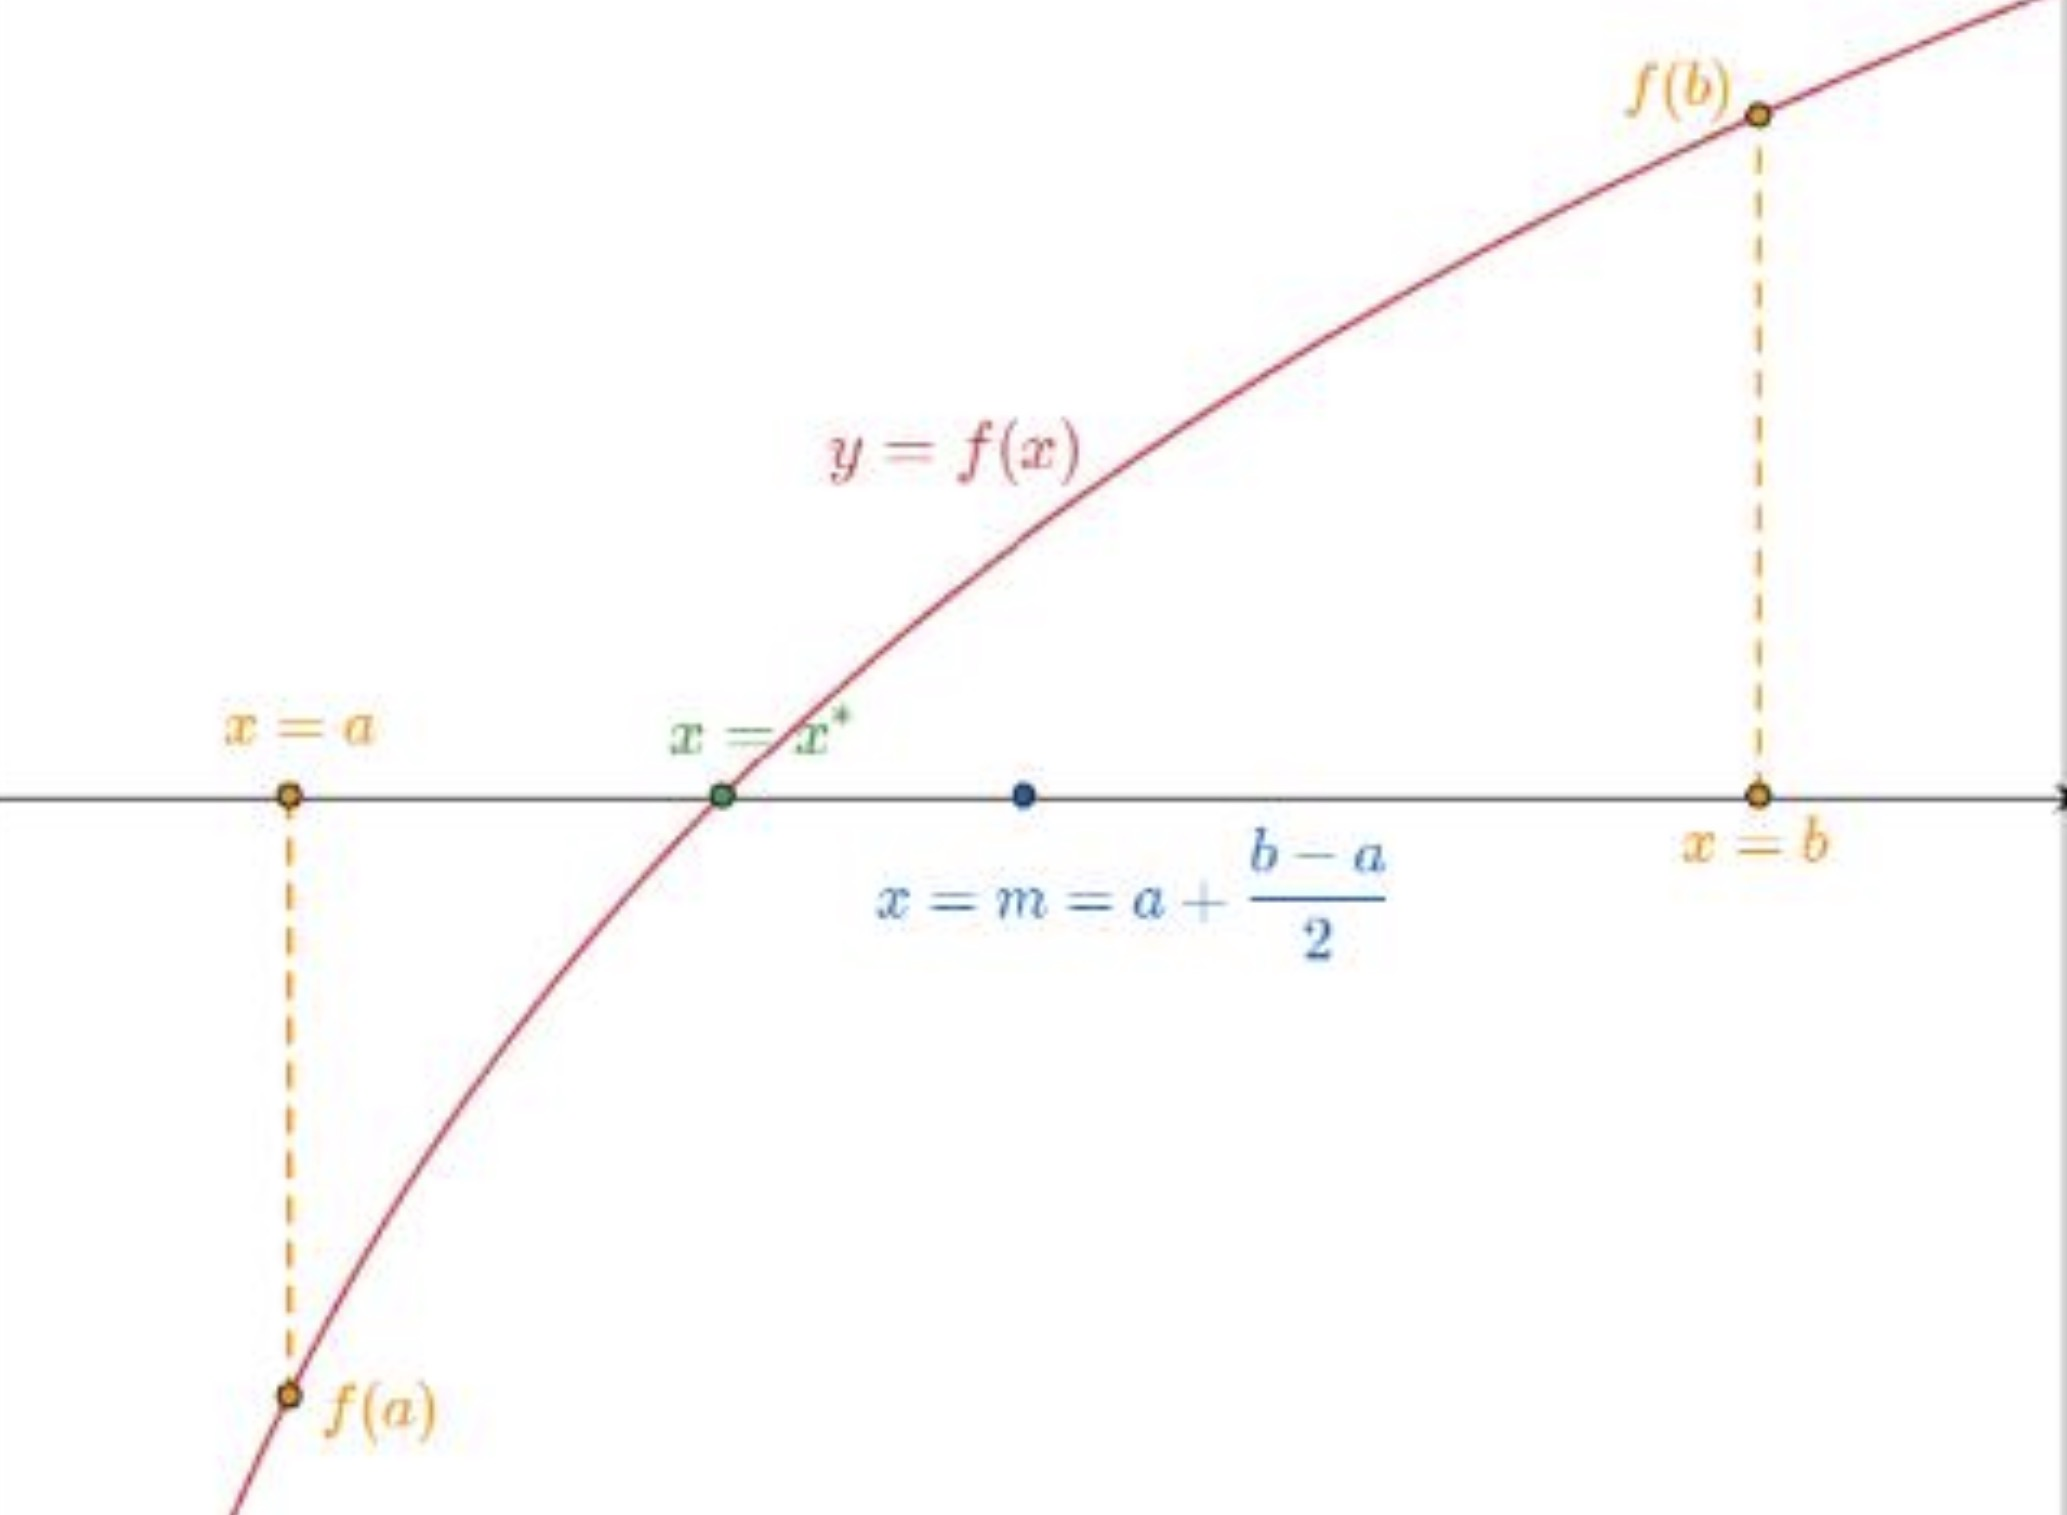

In [8]:
# Importamos las herramientas necesarias para mostrar la imagen
# Ilustración del método de bisección:
# se muestra cómo el intervalo [a,b] se divide por la mitad
# para aproximar progresivamente la raíz de la función.
from IPython.display import Image, display
display(Image(filename="Biseccion.jpg", width=400))

###Ejercicio: Algoritmo 2.1, página 37 del libro de Burden

##**Descripción**

En este ejercicio se aplica el método de bisección para encontrar una aproximación de la raíz de la función

$f(x)=x^3+4x^2-10$

en el intervalo $[1,2]$, con una precisión de $10^{-4}$.

Primero se evalúa la función en los extremos del intervalo, obteniendo

$f(1)=-5,\qquad f(2)=14.$

Como estos valores tienen signos opuestos, por el Teorema del Valor Intermedio se garantiza que existe al menos una raíz dentro del intervalo.

Posteriormente, en cada iteración se calcula el punto medio mediante

$p_n=a_n+\frac{b_n-a_n}{2}$

Después se evalúa la función en dicho punto y, de acuerdo con los signos de $f(a_n) y f(p_n)$, se selecciona el nuevo intervalo que contiene la raíz.

Criterio de parada: el proceso termina cuando el error, calculado como la longitud del intervalo $|b_n-a_n|$, es menor que la tolerancia $10^{-4}$, o cuando se alcanza el máximo de 100 iteraciones establecido.


In [2]:
# Importamos las librerías necesarias para realizar los cálculos
# y mostrar los resultados.
from math import *
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Definimos la función del ejercicio
def funcion1(x):
    return x**3 + 4*x**2 - 10

In [4]:
# Evaluamos la función
f=funcion1(1)

In [5]:
# Mostramos el valor de f(1)
print(f)

-5


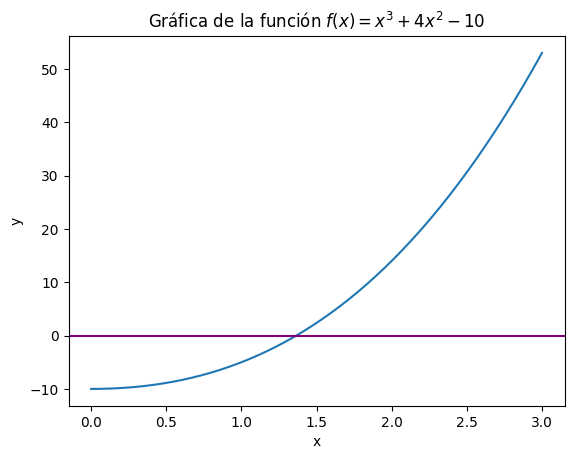

In [7]:
x=np.linspace(0,3) #genera una particion
plt.plot(x,funcion1(x))#muestra las parejas ordendas, (x,y)
plt.title('Gráfica de la función $f(x)=x^3+4x^2-10$')#titulo superior de la gráfica
plt.xlabel('x')
plt.ylabel('y')

plt.axhline(y=0,color='purple')#trazar linea horizontal en Y=0

###**Interpretación** **de** **la** **gráfica**

La curva de la función

$f(x)=x^3+4x^2-10$

presenta un comportamiento creciente en el intervalo $[1,2]$. Esto se puede comprobar mediante su derivada:

$f’(x)=3x^2+8x=x(3x+8)$

Para $x\in[1,2]$, tanto $(x)$ como $3x+8$ son positivos, por lo que

$f’(x)>0$

Por esta razón, la función es creciente en todo el intervalo. Al aumentar $x$, los valores de $f(x)$ también aumentan, hasta que la curva cruza el eje $x$ aproximadamente en

$x\approx1.3652.$

Este punto corresponde a la raíz que se busca aproximar mediante el método de bisección.

In [13]:
#Ingreso datos de entrada para los diferentes metodos a trabajad
a = 1
b = 2

#Guardar valores iniciales
a0 = a
b0 = b

#Guardar valores iniciales del error y del numero de iteraciones
tol = 0.00001 #float(input("Ingrese el valor de la tolerancia: "))
max = 100 #float(input("Ingrese el numero maximo de iteraciones: "))
error = 100
niter = 1

#Metodo de bisección

#evaluo primer valor medio

m = a + (b - a)/2

#Evaluacion de la función en los puntos a,b y m
fa = funcion1(a)
fb = funcion1(b)
fm = funcion1(m)

print("n\t\t an \t\t f(a) \t\t bn \t\t f(b) \t\t Pn \t\t f(Pn) \t\t error")
print("{0} \t\t {1:6.4f} \t {2:6.4f} \t {3:6.4f} \t {4:6.4f} \t {5:6.4f} \t {6:6.4f} \t {7:6.4f}".format(niter, a0, fa, b0, fb, m, fm, error ))

# ciclo iterativo
while error > tol and niter < max:
    m = a + (b - a) / 2
    if np.sign(fa) == np.sign(fm):
        a = m
        fa = funcion1(a)
    else:
        b = m
        fb = funcion1(b)

    m = a + (b - a)/2
    fm = funcion1(m)
    error = abs(b - a)
    niter += 1
    print("{0} \t\t {1:6.6f} \t {2:6.6f} \t {3:6.6f} \t {4:6.6f} \t {5:6.6f} \t {6:6.6f} \t {7:6.6f}".format(niter, a, fa, b, fb, m, fm, error ))

print("La raíz de la función dada en el intervalo [{0:6.4f},{1:6.4f}] es {2:6.7f}".format(a0,b0,m))


n		 an 		 f(a) 		 bn 		 f(b) 		 Pn 		 f(Pn) 		 error
1 		 1.0000 	 -5.0000 	 2.0000 	 14.0000 	 1.5000 	 2.3750 	 100.0000
2 		 1.000000 	 -5.000000 	 1.500000 	 2.375000 	 1.250000 	 -1.796875 	 0.500000
3 		 1.250000 	 -1.796875 	 1.500000 	 2.375000 	 1.375000 	 0.162109 	 0.250000
4 		 1.250000 	 -1.796875 	 1.375000 	 0.162109 	 1.312500 	 -0.848389 	 0.125000
5 		 1.312500 	 -0.848389 	 1.375000 	 0.162109 	 1.343750 	 -0.350983 	 0.062500
6 		 1.343750 	 -0.350983 	 1.375000 	 0.162109 	 1.359375 	 -0.096409 	 0.031250
7 		 1.359375 	 -0.096409 	 1.375000 	 0.162109 	 1.367188 	 0.032356 	 0.015625
8 		 1.359375 	 -0.096409 	 1.367188 	 0.032356 	 1.363281 	 -0.032150 	 0.007812
9 		 1.363281 	 -0.032150 	 1.367188 	 0.032356 	 1.365234 	 0.000072 	 0.003906
10 		 1.363281 	 -0.032150 	 1.365234 	 0.000072 	 1.364258 	 -0.016047 	 0.001953
11 		 1.364258 	 -0.016047 	 1.365234 	 0.000072 	 1.364746 	 -0.007989 	 0.000977
12 		 1.364746 	 -0.007989 	 1.365234 	 0.000072 	 1.36499



La tabla presenta las iteraciones realizadas mediante el método de bisección para aproximar la raíz de

$f(x)=x^3+4x^2-10$

en el intervalo inicial $[1,2]$. La columna $n$ indica el número de iteración, mientras que $(a_n)$ y $(b_n)$ representan los extremos del intervalo. En cada iteración se calcula el punto medio

$p_n=\frac{a_n+b_n}{2}$

y se evalúa $f(p_n)$ para determinar qué subintervalo conserva el cambio de signo.

De esta manera, el intervalo se reduce progresivamente y los valores de $(p_n)$ se acercan a la raíz. En el código, el criterio de parada se establece mediante una tolerancia de

$10^{-4},$

por lo que el proceso continúa mientras

$|b_n-a_n|>10^{-4}$

Cuando se cumple

$|b_n-a_n|<10^{-4},$

el intervalo se considera suficientemente pequeño y se detiene el proceso. Además, se establece un máximo de 100 iteraciones para evitar que el programa continúe indefinidamente.


Finalmente, la tabla permite observar cómo el intervalo se va reduciendo hasta obtener una aproximación de la raíz con la precisión solicitada.